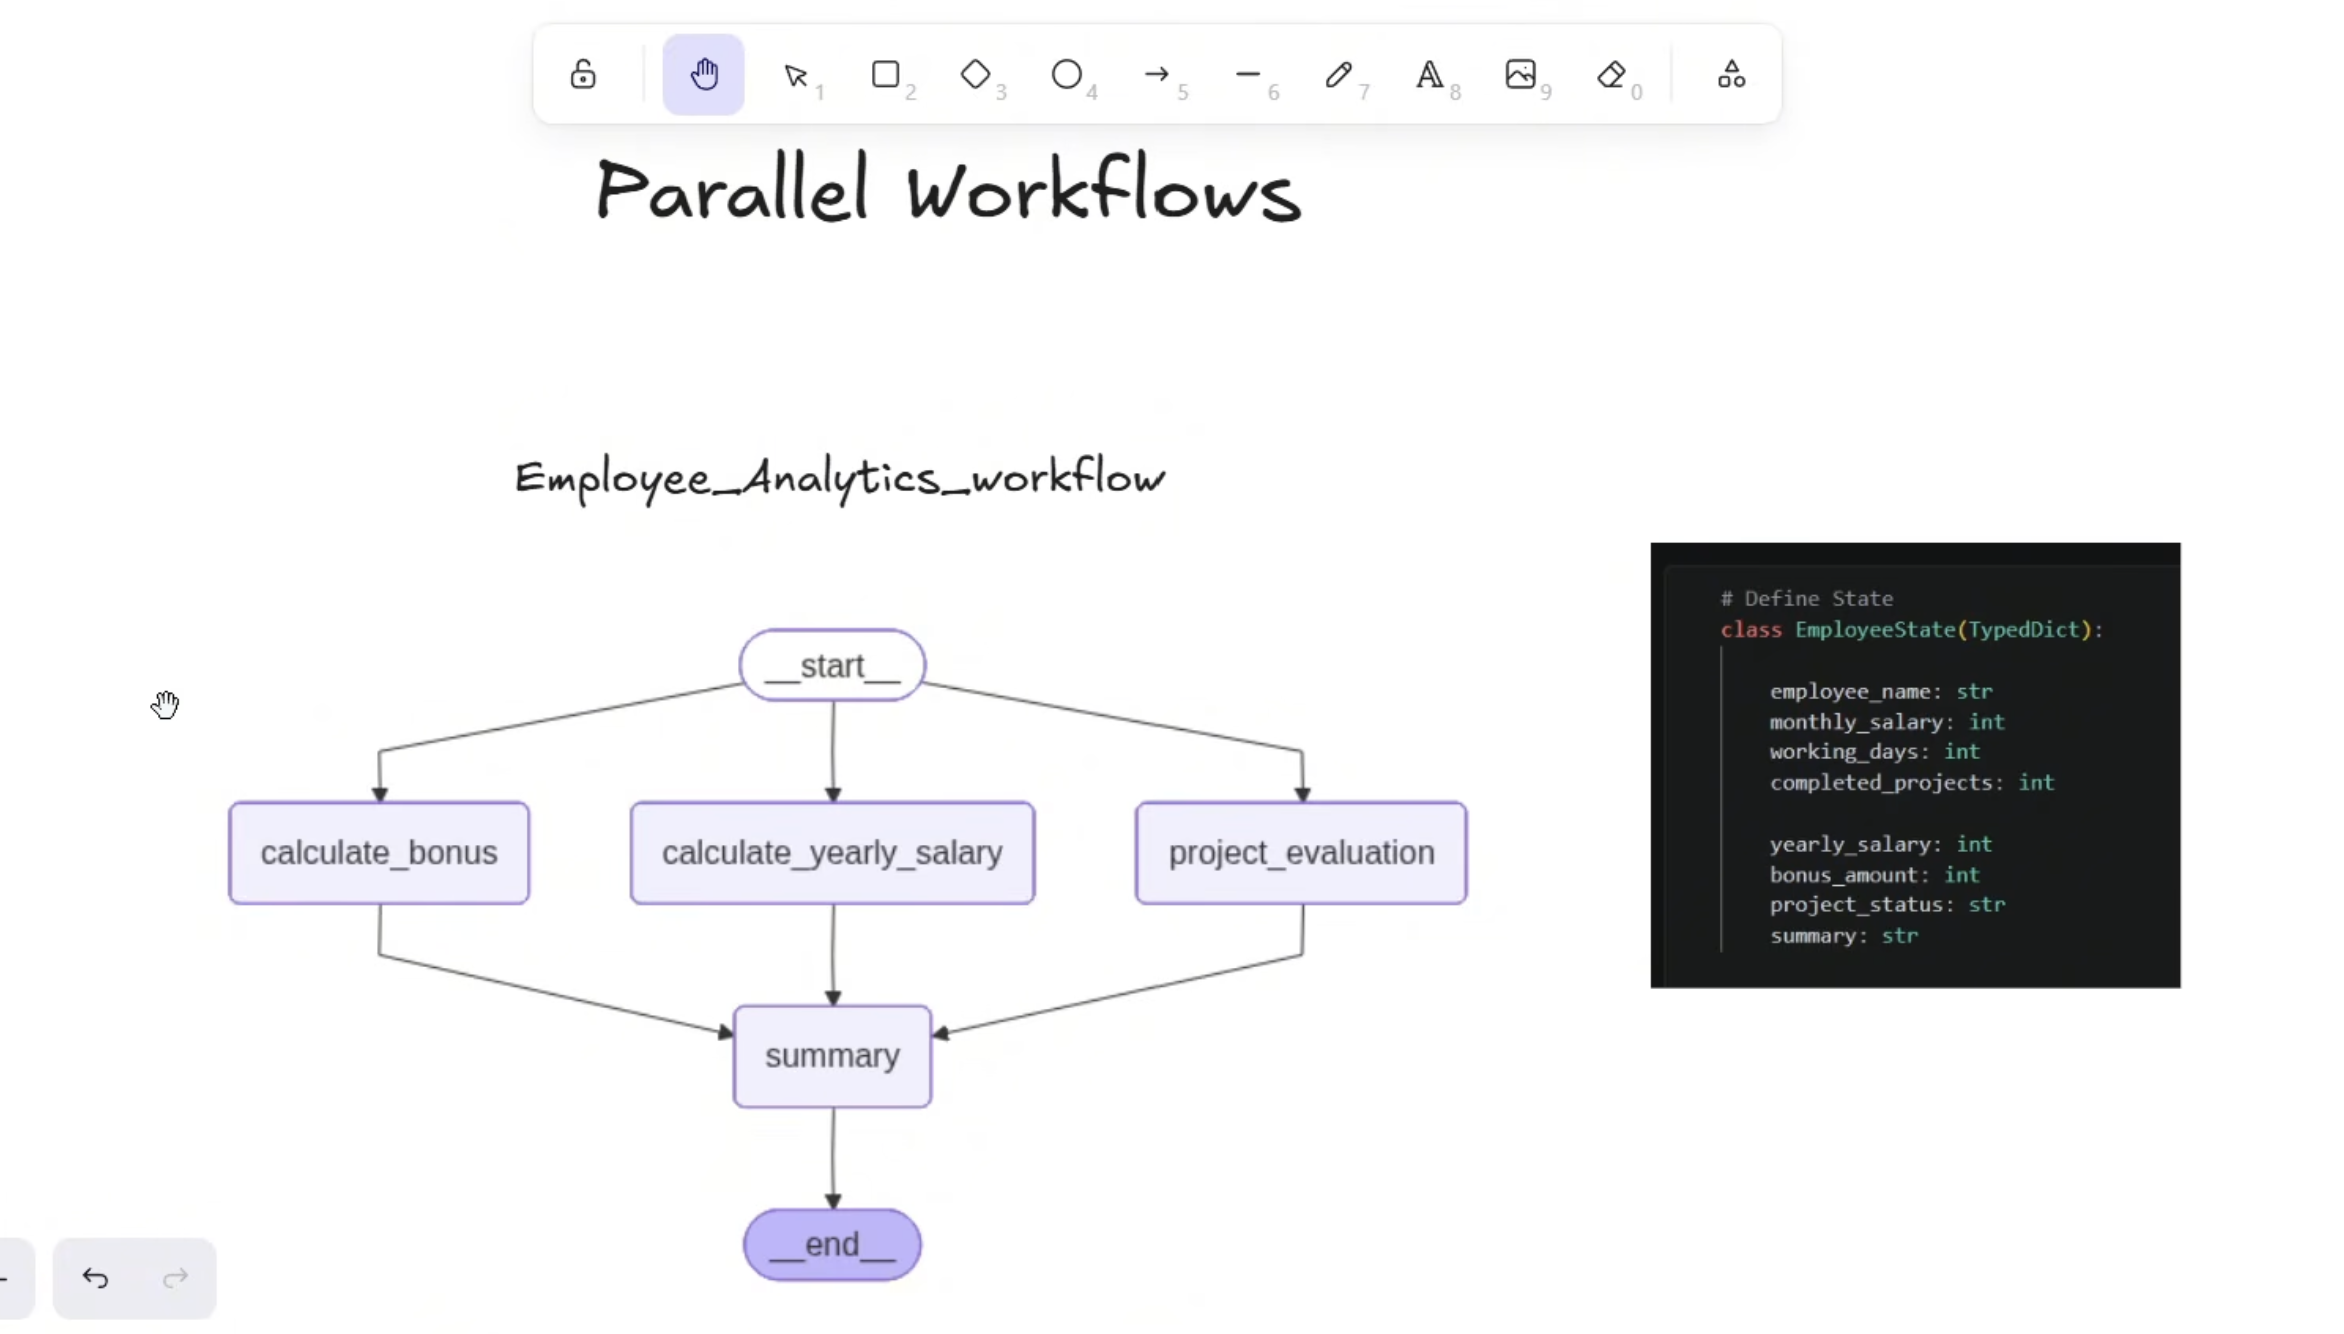

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
# Define State
class EmployeeState(TypedDict):

    employee_name: str
    monthly_salary: int
    working_days: int
    completed_projects: int

    yearly_salary: int
    bonus_amount: int
    project_status: str
    summary: str
    

In [4]:
# # Node 1 - Calculate Yearly Salary

def calculate_yearly_salary(state: EmployeeState):
    yearly_salary = state['monthly_salary'] * 12
  
    return {
        'yearly_salary': yearly_salary
    }

In [5]:
# Node 2 - Calculate Bonus
def calculate_bonus(state: EmployeeState):
    bonus_amount = state['monthly_salary'] * 2
    return {
        'bonus_amount': bonus_amount
    }

In [6]:
# Node 3 - Project Evaluation

def project_evaluation(state: EmployeeState):
    if state['completed_projects'] >= 5:
        status = 'Excellent'
    else:
        status = 'Average'

    return {
        'project_status': status
    }

In [7]:
# Summary Node
def summary(state: EmployeeState):
    summary_text = f"Employee {state['employee_name']} has a yearly salary of {state['yearly_salary']} and a bonus of {state['bonus_amount']}. Project status is {state['project_status']}."
    return {
        'summary': summary_text
    }

In [8]:
# Create Graph

graph = StateGraph(EmployeeState)

# Add Nodes

graph.add_node('calculate_yearly_salary', calculate_yearly_salary)
graph.add_node('calculate_bonus', calculate_bonus)
graph.add_node('project_evaluation', project_evaluation)
graph.add_node('summary', summary)

# Add Edges
graph.add_edge(START, 'calculate_yearly_salary')
graph.add_edge(START, 'calculate_bonus')
graph.add_edge(START, 'project_evaluation')

graph.add_edge('calculate_yearly_salary', 'summary')
graph.add_edge('calculate_bonus', 'summary')
graph.add_edge('project_evaluation', 'summary')

graph.add_edge('summary', END)



# Compile Workflow

workflow = graph.compile()

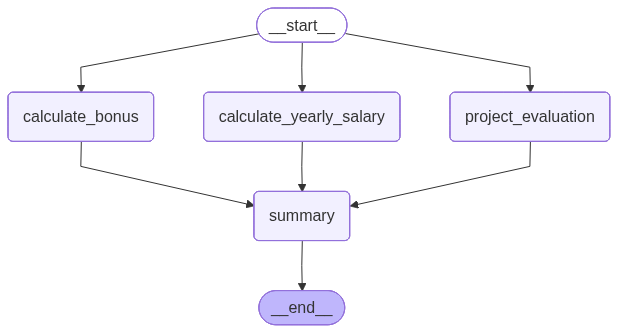

In [9]:
workflow

In [10]:
# Initial Input

initial_state = {
    'employee_name': 'Bappy',
    'monthly_salary': 50000,
    'working_days': 26,
    'completed_projects': 7
}

# Run Workflow

result = workflow.invoke(initial_state)

In [11]:
result

{'employee_name': 'Bappy',
 'monthly_salary': 50000,
 'working_days': 26,
 'completed_projects': 7,
 'yearly_salary': 600000,
 'bonus_amount': 100000,
 'project_status': 'Excellent',
 'summary': 'Employee Bappy has a yearly salary of 600000 and a bonus of 100000. Project status is Excellent.'}